In [ ]:
import kagglehub
iqothnccd_lung_cancer_dataset = kagglehub.dataset_download('adityamahimkar/iqothnccd-lung-cancer-dataset')
print("Dataset download from : ", iqothnccd_lung_cancer_dataset)
print("Data source import complete.")

100%|██████████| 199M/199M [00:01<00:00, 139MB/s]

Extracting files...


Dataset download from :  /root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2
Data source import complete.


In [ ]:
import os

# Get the path to the downloaded dataset
dataset_path = iqothnccd_lung_cancer_dataset

# List the contents of the dataset directory
print(f"Contents of the dataset directory: {dataset_path}")

# For Loop search entire directory
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)

    # For Loop to iterated every single images
    for f in files:
        print(f'{subindent}{f}')

Contents of the dataset directory: /root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2
2/
    Test cases/
        000058_07_01_170.png
        000143_04_02_153.png
        000230_04_01_174.png
        000315_04_03_094.png
        000230_03_02_166.png
        000103_02_01_107.png
        000198_05_01_124.png
        000188_03_01_146.png
        000271_12_02_237.png
        000874_03_02_219.png
        000271_12_02_242.png
        000247_03_01_202.png
        000027_02_01_105.png
        000103_05_01_136.png
        000569_08_01_020.png
        000021_01_01_016.png
        000058_06_02_223.png
        000207_04_01_068.png
        000198_05_01_112.png
        000103_03_01_166.png
        000306_06_02_126.png
        000103_01_01_173.png
        000228_03_03_165.png
        000103_12_01_075.png
        000020_01_01_066.png
        000238_10_02_152.png
        000020_04_01_159.png
        000284_01_02_105.png
        004085_01_02_107.png
        002265_01

# Task
Train a DenseNet169 model to classify lung cancer images into "Bengin cases", "Malignant cases", and "Normal cases" using the images from "/root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases", "/root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases", and "/root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases". The model should then be evaluated on a test set.

## Identify image categories and paths

### Subtask:
Extract the paths for 'Bengin cases', 'Malignant cases', and 'Normal cases' to organize the dataset for training and testing.


**Reasoning**:
I will construct the full paths for 'Normal cases', 'Malignant cases', and 'Bengin cases' by combining the base dataset path with the relevant subdirectories and folder names. Then, I will print these paths to ensure they are correctly identified.



In [ ]:
import os

# Ensure dataset_path is defined if the previous cell was not run or kernel reset
dataset_path = iqothnccd_lung_cancer_dataset

# Construct the full path to the parent directory containing the case folders
parent_dir = os.path.join(dataset_path, 'The IQ-OTHNCCD lung cancer dataset', 'The IQ-OTHNCCD lung cancer dataset')

# Define paths for each case type
normal_cases_path = os.path.join(parent_dir, 'Normal cases')
malignant_cases_path = os.path.join(parent_dir, 'Malignant cases')
benign_cases_path = os.path.join(parent_dir, 'Benign cases')

# Print the paths to verify
print(f"Normal cases path: {normal_cases_path}")
print(f"Malignant cases path: {malignant_cases_path}")
print(f"Bengin cases path: {benign_cases_path}")

Normal cases path: /root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases
Malignant cases path: /root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases
Bengin cases path: /root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Benign cases


## Load and preprocess images

### Subtask:
Load the images from the identified paths, resize them, and apply any necessary preprocessing steps (e.g., normalization) suitable for DenseNet169.


**Reasoning**:
I will import the necessary `ImageDataGenerator` class, define image dimensions and batch size, and then create `ImageDataGenerator` instances for training and validation. These generators will be configured with appropriate preprocessing and data augmentation techniques, and will load images from the `parent_dir` using `flow_from_directory`.



In [ ]:
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32 # Model can look 32 Images

# Create an ImageDataGenerator for training data with augmentation and rescaling
train_datagen = ImageDataGenerator(
  rescale=1./255, # Normalizing the image color
  rotation_range=40, # Rotating the image
  width_shift_range=0.2, # Shifting the image horizontally
  height_shift_range=0.2, # Shifting the image vertically
  shear_range=0.2, # Skewing or tilting the image
  zoom_range=0.2, # Zoomed in or zoomed out Randomly
  horizontal_flip=True, # Flipping the image horizontally
  brightness_range=[0.5, 1.5], # Adjusting the brightness
  fill_mode='nearest', # When we rotate, shift, or zoom images
  validation_split=0.2 # 20% for validation
)

# Create an ImageDataGenerator for validation/test data (only rescaling)
validation_datagen = ImageDataGenerator(
  rescale=1./255, # Normalizing the image color
  validation_split=0.2
  # 20% data for validation
  # 80% data for training
)

# Create a training data generator
train_generator = train_datagen.flow_from_directory(
  parent_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  subset='training',
  seed=42
)

# Load images from the parent_dir for validation
validation_generator = validation_datagen.flow_from_directory(
  parent_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  subset='validation',
  seed=42
)

print("Image data generators created successfully.")

Found 878 images belonging to 3 classes.
Found 219 images belonging to 3 classes.
Image data generators created successfully.


## Split data into training, validation, and test sets

### Subtask:
Create distinct generators for the training, validation, and test datasets from the image directory, ensuring proper splitting for a 3-way partition.


**Reasoning**:
I need to define two ImageDataGenerator instances to properly split the dataset into training, validation, and test sets according to the specified proportions and then create the respective generators using `flow_from_directory` with appropriate subsets and configurations. Finally, I'll print the number of samples in each to confirm the split.



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size (already defined, using existing variables)
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# 1. Define a train_val_datagen using ImageDataGenerator with data augmentation
train_val_datagen = ImageDataGenerator(
  rescale=1./255,
  rotation_range=40,
  width_shift_range=0.2,
  height_shift_range=0.2,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True,
  brightness_range=[0.5, 1.5],
  fill_mode='nearest',
  validation_split=0.3 # 30% for validation and testing combined
)

# 2. Create the train_generator
train_generator = train_val_datagen.flow_from_directory(
  parent_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  subset='training',
  seed=42
)

# 3. Define a test_val_datagen using ImageDataGenerator with only rescaling
test_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.5 # Split the 30% into 15% validation, 15% test
)

# 4. Create the validation_generator
validation_generator = test_val_datagen.flow_from_directory(
    parent_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

# 5. Create the test_generator
test_generator = test_val_datagen.flow_from_directory(
    parent_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

# 6. Print the number of images in each generator to verify the split
print(f"Training images: {train_generator.samples}")
print(f"Validation images: {validation_generator.samples}")
print(f"Test images: {test_generator.samples}")

print("Training, validation, and test data generators created successfully.")

Found 769 images belonging to 3 classes.
Found 549 images belonging to 3 classes.
Found 548 images belonging to 3 classes.
Training images: 769
Validation images: 549
Test images: 548
Training, validation, and test data generators created successfully.


## Define and build the DenseNet169 model

### Subtask:
Construct the DenseNet169 architecture, potentially adding custom classification layers on top of a pre-trained base.


**Reasoning**:
I will construct the DenseNet169 model by importing necessary Keras components, loading the pre-trained DenseNet169 base, adding custom classification layers for GlobalAveragePooling2D, Dense, and Dropout, and finally print the model summary to verify its architecture.



In [ ]:
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, GlobalAveragePooling2D, Dropout

# 1. Load the DenseNet169 base model, pre-trained on 'imagenet' weights
#    Exclude the top classification layer
base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the base model layers so they are not updated during training
for layer in base_model.layers:
    layer.trainable = False

# 2. Create a Sequential model
model = Sequential()

# 3. Add the loaded DenseNet169 base model to the sequential model
model.add(base_model)

# 4. Add a GlobalAveragePooling2D layer
model.add(GlobalAveragePooling2D())

# 5. Add a Dense layer with 256 units and 'relu' activation
model.add(Dense(256, activation='relu'))

# 6. Add a Dropout layer with a rate of 0.5
model.add(Dropout(0.5))

# 7. Add a final Dense layer with the number of output classes and 'softmax' activation
# The number of classes is 3 (Bengin, Malignant, Normal)
num_classes = train_generator.num_classes
model.add(Dense(num_classes, activation='softmax'))

# 8. Print the model summary
model.summary()

print("DenseNet169 model with custom classification layers built successfully.")

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       426,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,069,891 (49.86 MB)

 Trainable params: 427,011 (1.63 MB)

 Non-trainable params: 12,642,880 (48.23 MB)

DenseNet169 model with custom classification layers built successfully.


## Compile and train the model

### Subtask:
Compile the DenseNet169 model with an appropriate optimizer, loss function, and metrics, then train it using the prepared training and validation data.


**Reasoning**:
I will compile the DenseNet169 model with the Adam optimizer, categorical crossentropy loss, and accuracy metrics, then train it for 10 epochs using the training and validation data generators to begin the model training process.



In [ ]:
from tensorflow.keras.optimizers import Adam

# Tuning Hyper parameter :
# Learning Rate = 0.0001
# Learning Rate = 0.001
# Learning Rate = 0.01

# 1. Compile the model
model.compile(
  optimizer=Adam(learning_rate=0.01), # Using Adam optimizer with a default learning rate
  loss='categorical_crossentropy',     # Suitable for multi-class classification with one-hot encoded labels
  metrics=['accuracy']                 # Track accuracy during training
)

print("Model compiled successfully.")

# 2. Train the model
history = model.fit(
    train_generator,
    epochs=20, # As specified in the instructions
    validation_data=validation_generator
)

print("Model training completed.")

Model compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step - accuracy: 0.5240 - loss: 5.9657 - val_accuracy: 0.7996 - val_loss: 0.7146
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.7129 - loss: 0.7416 - val_accuracy: 0.8379 - val_loss: 0.4188
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.8061 - loss: 0.5184 - val_accuracy: 0.7760 - val_loss: 0.6181
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 114s 5s/step - accuracy: 0.7094 - loss: 0.7131 - val_accuracy: 0.8306 - val_loss: 0.4458
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.7849 - loss: 0.5342 - val_accuracy: 0.8761 - val_loss: 0.3770
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.8149 - loss: 0.5071 - val_accuracy: 0.8725 - val_loss: 0.3186
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.7950 - loss: 0.5203 - val_accuracy: 0.8616 - val_loss: 0.3374
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.8142 - loss: 0.4675 - val_accuracy: 0.8652 - v

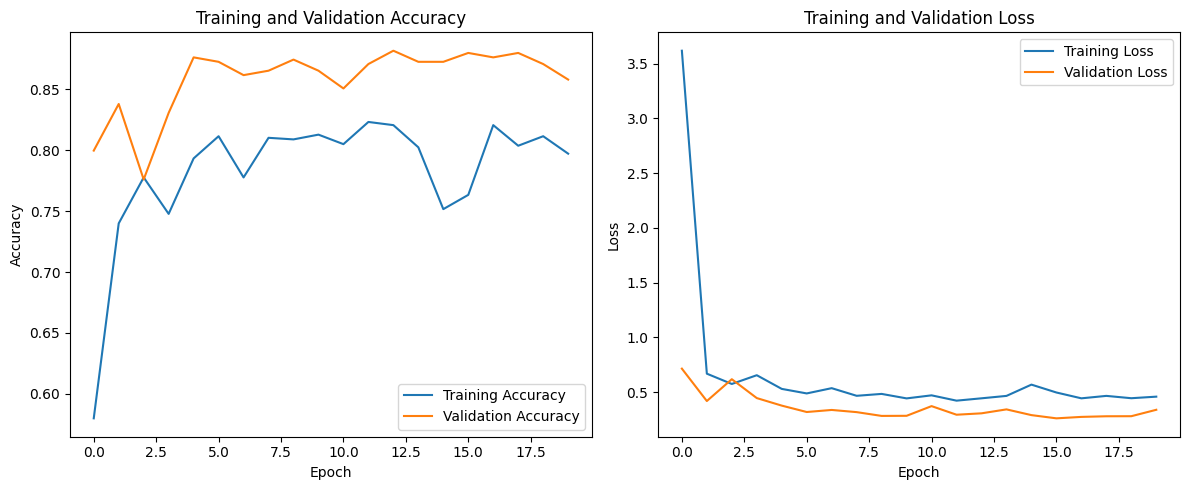

In [14]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# Evaluate the model on the test data
import time
start_time = time.time()
loss, test_accuracy = model.evaluate(test_generator)
end_time = time.time()
total_time = end_time - start_time

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Total Test Time: {total_time:.2f} seconds")

18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.8594 - loss: 0.4567
Test Loss: 0.4681
Test Accuracy: 0.8595
Total Test Time: 46.36 seconds
